✅ Toutes les librairies sont chargées !
📊 Génération du dataset...
✅ Dataset généré : 1000 patients
   - Patients non-adhérents : 134 (13.4%)
   - Patients adhérents : 866 (86.6%)

📊 Aperçu des données :
         age  gender  education_level  income_level  diabetes_duration  \
0  63.960570       1                1             1           1.238922   
1  56.340828       1                0             0           1.313768   
2  65.772262       0                0             0           4.535944   
3  76.276358       0                1             2           7.244386   
4  55.190160       1                2             1           0.672406   

       hba1c  complications_count  pharmacy_visits_per_year  \
0  11.023614                    3                         8   
1   6.425935                    1                         4   
2   6.875062                    1                         3   
3   7.405315                    0                         4   
4   8.093698                    1   

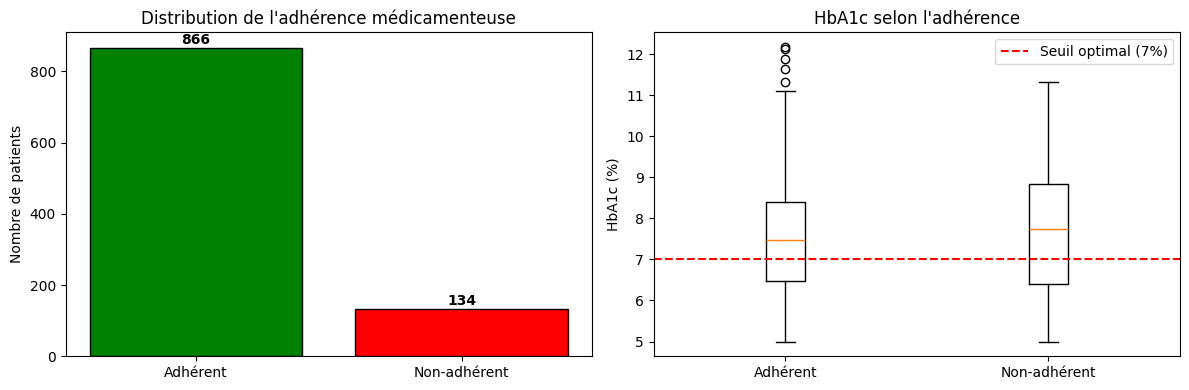


🔧 Prétraitement des données...
✅ Train set : 800 patients
✅ Test set : 200 patients
   - Adhérents test : 173
   - Non-adhérents test : 27

⚖️ Application de SMOTE pour équilibrer les classes...
   - Après SMOTE : 1386 samples
   - Non-adhérents : 693 (50.0%)

ENTRAÎNEMENT DES MODÈLES

📈 Entraînement de Régression Logistique...
   ✅ Accuracy : 0.8400
   ✅ Precision : 0.4419
   ✅ Recall : 0.7037
   ✅ F1-Score : 0.5429
   ✅ AUC : 0.9052
   ✅ CV F1 (5-fold) : 0.8614 ± 0.0148

📈 Entraînement de Random Forest...
   ✅ Accuracy : 0.9000
   ✅ Precision : 0.7059
   ✅ Recall : 0.4444
   ✅ F1-Score : 0.5455
   ✅ AUC : 0.9135
   ✅ CV F1 (5-fold) : 0.9578 ± 0.0268

📈 Entraînement de SVM...
   ✅ Accuracy : 0.8850
   ✅ Precision : 0.5667
   ✅ Recall : 0.6296
   ✅ F1-Score : 0.5965
   ✅ AUC : 0.9133
   ✅ CV F1 (5-fold) : 0.9481 ± 0.0068

📈 Entraînement de XGBoost...
   ✅ Accuracy : 0.9000
   ✅ Precision : 0.6667
   ✅ Recall : 0.5185
   ✅ F1-Score : 0.5833
   ✅ AUC : 0.9171
   ✅ CV F1 (5-fold) : 0.942

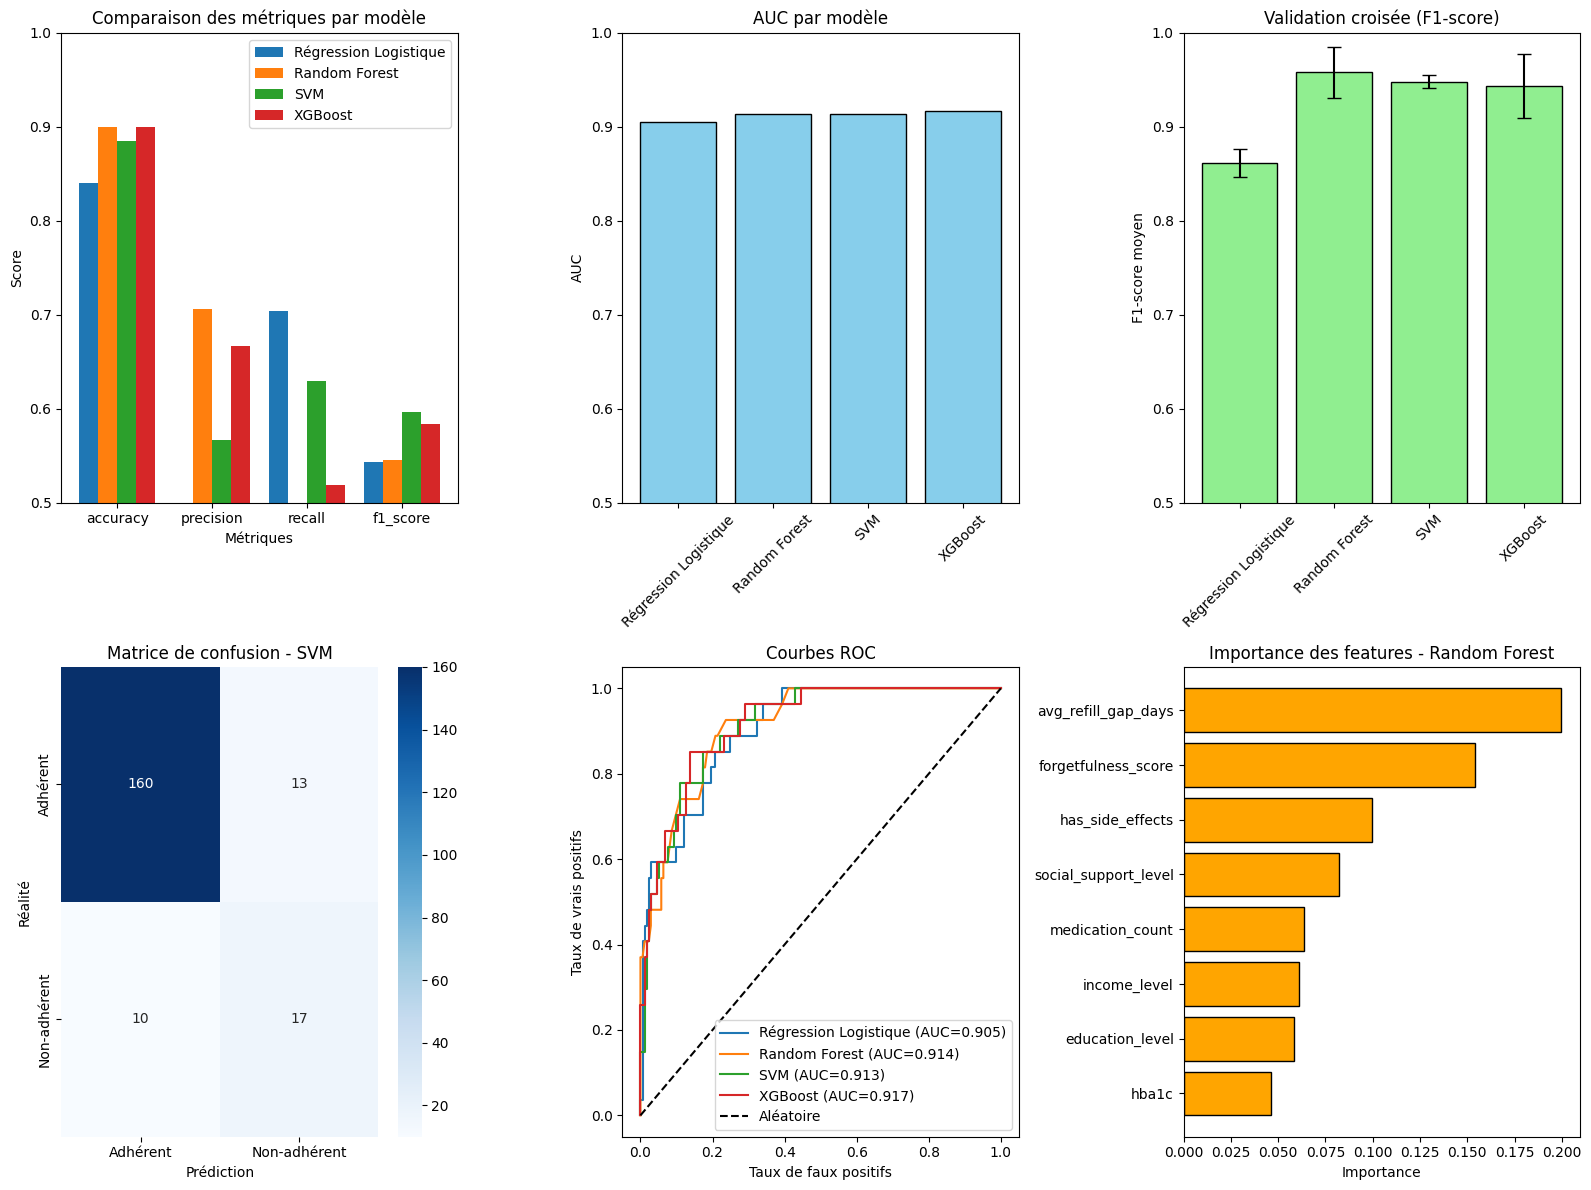


ANALYSE PAR QUARTILES DE RISQUE

📊 Distribution du risque par quartile :
                 non_adherent  hba1c  diabetes_duration
risk_quartile                                          
Q1 (Faible)             0.000  7.135              6.835
Q2 (Modéré)             0.004  7.348              8.367
Q3 (Élevé)              0.012  7.785              8.071
Q4 (Très élevé)         0.520  7.665              7.687


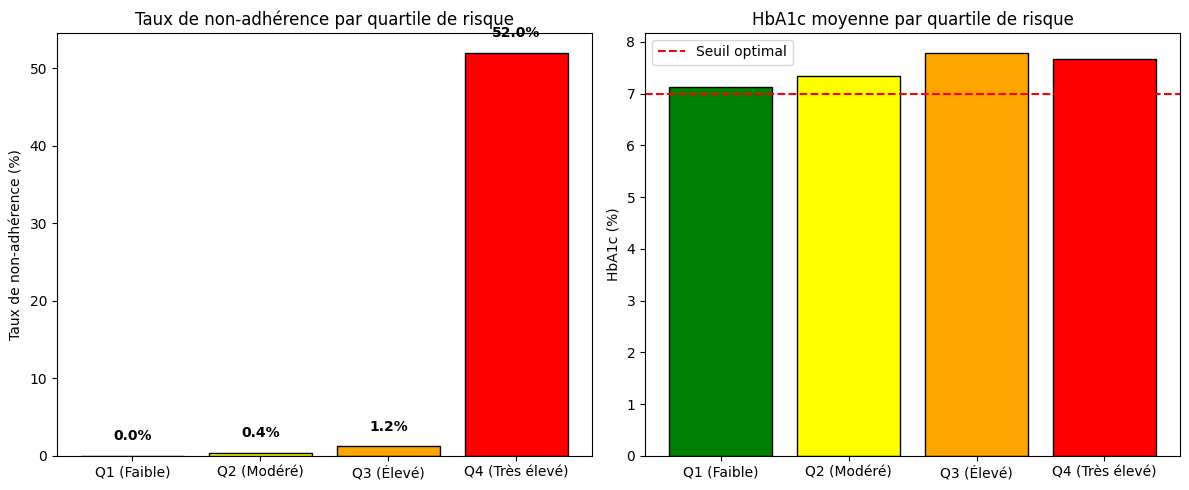


CONCLUSION

🏆 MEILLEUR MODÈLE : SVM
   - F1-Score : 0.5965
   - Accuracy : 0.8850
   - AUC : 0.9133

📊 RÉSUMÉ DES PERFORMANCES :
   Régression Logistique : F1 = 0.5429 | AUC = 0.9052
   Random Forest        : F1 = 0.5455 | AUC = 0.9135
   SVM                  : F1 = 0.5965 | AUC = 0.9133
   XGBoost              : F1 = 0.5833 | AUC = 0.9171

📈 IMPACT CLINIQUE :
   - Patients en Q4 (très haut risque) : 250 patients
   - Taux de non-adhérence en Q4 : 52.0%
   - HbA1c moyenne en Q4 : 7.7% (vs seuil 7%)

✅ Projet terminé avec succès !


In [1]:
# ============================================
# PROJET D1 : Prédiction de la non-adhérence au traitement
# Diabète de type 2
# ============================================

# ----- CELLULE 1 : Installation des librairies -----
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost imbalanced-learn

# ----- CELLULE 2 : Imports -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ Toutes les librairies sont chargées !")

# ----- CELLULE 3 : Création du dataset synthétique -----
# (Basé sur les caractéristiques identifiées dans la littérature)
print("📊 Génération du dataset...")

np.random.seed(42)
n_patients = 1000

# Caractéristiques démographiques
age = np.random.normal(58, 12, n_patients).clip(18, 90)
gender = np.random.binomial(1, 0.55, n_patients)  # 1 = femme
education = np.random.choice([0, 1, 2, 3], n_patients, p=[0.2, 0.35, 0.3, 0.15])  # 0:faible, 3:élevé
income = np.random.choice([0, 1, 2], n_patients, p=[0.4, 0.35, 0.25])  # 0:bas, 2:haut

# Caractéristiques cliniques
diabetes_duration = np.random.exponential(8, n_patients).clip(0.5, 30)
hba1c = np.random.normal(7.5, 1.5, n_patients).clip(5, 14)
complications = np.random.poisson(0.8, n_patients).clip(0, 5)  # nb de complications

# Caractéristiques comportementales
pharmacy_visits = np.random.poisson(4, n_patients).clip(1, 12)
refill_gaps = np.random.exponential(15, n_patients).clip(0, 90)  # jours de retard
forgetfulness_score = np.random.beta(2, 5, n_patients) * 10  # 0-10
side_effects = np.random.binomial(1, 0.25, n_patients)  # présence d'effets secondaires
medication_count = np.random.poisson(2, n_patients).clip(1, 8)  # nb de médicaments

# Facteurs socio-économiques
insurance = np.random.binomial(1, 0.85, n_patients)  # 1 = assurance
distance_to_pharmacy = np.random.exponential(10, n_patients).clip(1, 50)  # km
social_support = np.random.choice([0, 1, 2], n_patients, p=[0.2, 0.5, 0.3])  # 0:faible, 2:fort

# Création du DataFrame
data = pd.DataFrame({
    'age': age,
    'gender': gender,
    'education_level': education,
    'income_level': income,
    'diabetes_duration': diabetes_duration,
    'hba1c': hba1c,
    'complications_count': complications,
    'pharmacy_visits_per_year': pharmacy_visits,
    'avg_refill_gap_days': refill_gaps,
    'forgetfulness_score': forgetfulness_score,
    'has_side_effects': side_effects,
    'medication_count': medication_count,
    'has_insurance': insurance,
    'distance_to_pharmacy_km': distance_to_pharmacy,
    'social_support_level': social_support
})

# Génération de la variable cible (non-adhérence)
# Logique basée sur la littérature
adherence_risk = (
    0.15 * (forgetfulness_score > 5) +
    0.12 * (refill_gaps > 20) +
    0.10 * (side_effects == 1) +
    0.08 * (medication_count > 3) +
    0.08 * (education < 1) +
    0.07 * (income == 0) +
    0.07 * (social_support == 0) +
    0.06 * (distance_to_pharmacy > 20) +
    0.05 * (insurance == 0) +
    0.05 * (hba1c > 8.5) +
    np.random.normal(0, 0.05, n_patients)
)

# Seuil pour classification binaire
adherence_prob = 1 / (1 + np.exp(-(adherence_risk - 0.3) * 5))
non_adherent = (adherence_prob > 0.5).astype(int)

data['non_adherent'] = non_adherent

print(f"✅ Dataset généré : {len(data)} patients")
print(f"   - Patients non-adhérents : {non_adherent.sum()} ({non_adherent.mean()*100:.1f}%)")
print(f"   - Patients adhérents : {(1-non_adherent).sum()} ({(1-non_adherent.mean())*100:.1f}%)")
print(f"\n📊 Aperçu des données :")
print(data.head())

# ----- CELLULE 4 : Analyse exploratoire -----
print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE")
print("="*60)

# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot de la cible
adherence_counts = data['non_adherent'].value_counts()
axes[0].bar(['Adhérent', 'Non-adhérent'], adherence_counts.values,
            color=['green', 'red'], edgecolor='black')
axes[0].set_title('Distribution de l\'adhérence médicamenteuse')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(adherence_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Comparaison HbA1c selon adhérence
adherent_hba1c = data[data['non_adherent']==0]['hba1c']
nonadherent_hba1c = data[data['non_adherent']==1]['hba1c']
axes[1].boxplot([adherent_hba1c, nonadherent_hba1c], labels=['Adhérent', 'Non-adhérent'])
axes[1].set_title('HbA1c selon l\'adhérence')
axes[1].set_ylabel('HbA1c (%)')
axes[1].axhline(y=7, color='r', linestyle='--', label='Seuil optimal (7%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('exploration_donnees.png', dpi=150)
plt.show()

# ----- CELLULE 5 : Prétraitement -----
print("\n🔧 Prétraitement des données...")

# Séparation features / target
feature_cols = [col for col in data.columns if col != 'non_adherent']
X = data[feature_cols]
y = data['non_adherent']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set : {len(X_train)} patients")
print(f"✅ Test set : {len(X_test)} patients")
print(f"   - Adhérents test : {(1-y_test).sum()}")
print(f"   - Non-adhérents test : {y_test.sum()}")

# Application de SMOTE pour rééquilibrage
print("\n⚖️ Application de SMOTE pour équilibrer les classes...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"   - Après SMOTE : {len(X_train_balanced)} samples")
print(f"   - Non-adhérents : {y_train_balanced.sum()} ({(y_train_balanced.sum()/len(y_train_balanced))*100:.1f}%)")

# ----- CELLULE 6 : Définition et entraînement des 4 modèles -----
print("\n" + "="*60)
print("ENTRAÎNEMENT DES MODÈLES")
print("="*60)

models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\n📈 Entraînement de {name}...")

    # Entraînement sur données équilibrées
    model.fit(X_train_balanced, y_train_balanced)

    # Prédictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    # Validation croisée
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5, scoring='f1')

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_proba,
        'model': model
    }

    print(f"   ✅ Accuracy : {accuracy:.4f}")
    print(f"   ✅ Precision : {precision:.4f}")
    print(f"   ✅ Recall : {recall:.4f}")
    print(f"   ✅ F1-Score : {f1:.4f}")
    if auc:
        print(f"   ✅ AUC : {auc:.4f}")
    print(f"   ✅ CV F1 (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ----- CELLULE 7 : Tableau comparatif -----
print("\n" + "="*60)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*60)

comparison_df = pd.DataFrame(results).T
metrics_to_show = ['accuracy', 'precision', 'recall', 'f1_score', 'auc', 'cv_mean']
print(comparison_df[metrics_to_show].round(4))

# ----- CELLULE 8 : Visualisations -----
print("\n📊 Génération des visualisations...")

fig = plt.figure(figsize=(16, 12))

# 1. Barplot comparatif
ax1 = plt.subplot(2, 3, 1)
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(metrics))
width = 0.2
for i, (name, result) in enumerate(results.items()):
    values = [result[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=name)
ax1.set_xlabel('Métriques')
ax1.set_ylabel('Score')
ax1.set_title('Comparaison des métriques par modèle')
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim([0.5, 1.0])

# 2. AUC comparatif
ax2 = plt.subplot(2, 3, 2)
auc_values = [results[name]['auc'] for name in results.keys() if results[name]['auc'] is not None]
auc_names = [name for name in results.keys() if results[name]['auc'] is not None]
ax2.bar(auc_names, auc_values, color='skyblue', edgecolor='black')
ax2.set_title('AUC par modèle')
ax2.set_ylabel('AUC')
ax2.set_ylim([0.5, 1.0])
ax2.tick_params(axis='x', rotation=45)

# 3. Validation croisée
ax3 = plt.subplot(2, 3, 3)
cv_means = [results[name]['cv_mean'] for name in results.keys()]
cv_stds = [results[name]['cv_std'] for name in results.keys()]
ax3.bar(results.keys(), cv_means, yerr=cv_stds, capsize=5, color='lightgreen', edgecolor='black')
ax3.set_title('Validation croisée (F1-score)')
ax3.set_ylabel('F1-score moyen')
ax3.set_ylim([0.5, 1.0])
ax3.tick_params(axis='x', rotation=45)

# 4. Matrice de confusion - Meilleur modèle
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_model_results = results[best_model_name]

ax4 = plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test, best_model_results['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_title(f'Matrice de confusion - {best_model_name}')
ax4.set_xlabel('Prédiction')
ax4.set_ylabel('Réalité')
ax4.set_xticklabels(['Adhérent', 'Non-adhérent'])
ax4.set_yticklabels(['Adhérent', 'Non-adhérent'])

# 5. Courbes ROC
ax5 = plt.subplot(2, 3, 5)
for name, result in results.items():
    if result['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
        ax5.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.3f})")
ax5.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax5.set_xlabel('Taux de faux positifs')
ax5.set_ylabel('Taux de vrais positifs')
ax5.set_title('Courbes ROC')
ax5.legend(loc='lower right')

# 6. Importance des features (Random Forest)
ax6 = plt.subplot(2, 3, 6)
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-8:]
ax6.barh(np.array(feature_cols)[indices], importances[indices], color='orange', edgecolor='black')
ax6.set_title('Importance des features - Random Forest')
ax6.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('resultats_modeles.png', dpi=150)
plt.show()

# ----- CELLULE 9 : Analyse par quartiles de risque -----
print("\n" + "="*60)
print("ANALYSE PAR QUARTILES DE RISQUE")
print("="*60)

# Prédictions du meilleur modèle
best_model = results[best_model_name]['model']
risk_scores = best_model.predict_proba(X_scaled)[:, 1]

data_analysis = data.copy()
data_analysis['risk_score'] = risk_scores

# Division en quartiles
data_analysis['risk_quartile'] = pd.qcut(risk_scores, 4, labels=['Q1 (Faible)', 'Q2 (Modéré)', 'Q3 (Élevé)', 'Q4 (Très élevé)'])

print("\n📊 Distribution du risque par quartile :")
quartile_analysis = data_analysis.groupby('risk_quartile').agg({
    'non_adherent': 'mean',
    'hba1c': 'mean',
    'diabetes_duration': 'mean'
}).round(3)
print(quartile_analysis)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux de non-adhérence par quartile
axes[0].bar(quartile_analysis.index, quartile_analysis['non_adherent'] * 100,
            color=['green', 'yellow', 'orange', 'red'], edgecolor='black')
axes[0].set_title('Taux de non-adhérence par quartile de risque')
axes[0].set_ylabel('Taux de non-adhérence (%)')
for i, v in enumerate(quartile_analysis['non_adherent'] * 100):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# HbA1c par quartile
axes[1].bar(quartile_analysis.index, quartile_analysis['hba1c'],
            color=['green', 'yellow', 'orange', 'red'], edgecolor='black')
axes[1].set_title('HbA1c moyenne par quartile de risque')
axes[1].set_ylabel('HbA1c (%)')
axes[1].axhline(y=7, color='r', linestyle='--', label='Seuil optimal')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse_quartiles.png', dpi=150)
plt.show()

# ----- CELLULE 10 : Conclusion -----
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"   - F1-Score : {best_model_results['f1_score']:.4f}")
print(f"   - Accuracy : {best_model_results['accuracy']:.4f}")
print(f"   - AUC : {best_model_results['auc']:.4f}")

print("\n📊 RÉSUMÉ DES PERFORMANCES :")
for name in results.keys():
    print(f"   {name:20} : F1 = {results[name]['f1_score']:.4f} | AUC = {results[name]['auc']:.4f}")

print(f"\n📈 IMPACT CLINIQUE :")
print(f"   - Patients en Q4 (très haut risque) : {len(data_analysis[data_analysis['risk_quartile']=='Q4 (Très élevé)'])} patients")
print(f"   - Taux de non-adhérence en Q4 : {quartile_analysis.loc['Q4 (Très élevé)', 'non_adherent']*100:.1f}%")
print(f"   - HbA1c moyenne en Q4 : {quartile_analysis.loc['Q4 (Très élevé)', 'hba1c']:.1f}% (vs seuil 7%)")

print("\n✅ Projet terminé avec succès !")